# *PROJECT TITLE*
*Cloudflare Web Traffic Data Analysis: Bot Spike Detection & Monitoring*

# *Domain:* Website Monitoring & Analytics

This project analyzes real website traffic data to study bot and human usage patterns as part of IT infrastructure and web analytics


# *Objective*

* To analyze bot vs human web traffic trends over time using      timestamp-based data.
* To identify peak time periods with high bot activity in website traffic.
* To measure and compare traffic health status (Healthy vs Risky) across different time intervals.
* To generate visual reports (charts) and insights that support website traffic monitoring and security decision-making.

















# *Dataset Information*
Source

Cloudflare API Bot vs Human traffic dataset

Location

Global internet traffic data provided by Cloudflare Radar Official Webpage

TimeLine

For this project the dataset was collected as a snapshot during January 2026

From: 2026-01-30

To: 2026-02-02

# *Problem Definition*
* Websites receive traffic from both Humans and Bots.
* High bot traffic can cause fake visits, suspicious activity, and performance issues.
* It is important to monitor bot vs human traffic trends over time.
* This project focuses on detecting bot spikes and identifying high-risk time periods.

# *Data Collection*
* The dataset is collected from Cloudflare Radar Official API.
* An API Token was created in the Cloudflare Radar website for secure access.
* Using Python requests an API request was sent with the token-Bearer Authentication




In [ ]:
import requests
# Cloudflare API token created from cloudfare's webpage for authentication
API_TOKEN = "ihg5sTCBlcL9YSvX2OXQnEYL9K3j4cYy_2BJ8mZj"
url = "https://api.cloudflare.com/client/v4/radar/http/timeseries_groups/bot_class"
headers = {"Authorization": f"Bearer {API_TOKEN}"}
params = {"dateRange": "30d"}
#GET request to Cloudflare API
response = requests.get(url, headers=headers, params=params)
#print status code(HTTP)
print(response.status_code)
#Print API response in JSON format
print(response.json())

200
{'success': True, 'errors': [], 'result': {'serie_0': {'timestamps': ['2026-02-01T03:00:00Z', '2026-02-01T04:00:00Z', '2026-02-01T05:00:00Z', '2026-02-01T06:00:00Z', '2026-02-01T07:00:00Z', '2026-02-01T08:00:00Z', '2026-02-01T09:00:00Z', '2026-02-01T10:00:00Z', '2026-02-01T11:00:00Z', '2026-02-01T12:00:00Z', '2026-02-01T13:00:00Z', '2026-02-01T14:00:00Z', '2026-02-01T15:00:00Z', '2026-02-01T16:00:00Z', '2026-02-01T17:00:00Z', '2026-02-01T18:00:00Z', '2026-02-01T19:00:00Z', '2026-02-01T20:00:00Z', '2026-02-01T21:00:00Z', '2026-02-01T22:00:00Z', '2026-02-01T23:00:00Z', '2026-02-02T00:00:00Z', '2026-02-02T01:00:00Z', '2026-02-02T02:00:00Z', '2026-02-02T03:00:00Z', '2026-02-02T04:00:00Z', '2026-02-02T05:00:00Z', '2026-02-02T06:00:00Z', '2026-02-02T07:00:00Z', '2026-02-02T08:00:00Z', '2026-02-02T09:00:00Z', '2026-02-02T10:00:00Z', '2026-02-02T11:00:00Z', '2026-02-02T12:00:00Z', '2026-02-02T13:00:00Z', '2026-02-02T14:00:00Z', '2026-02-02T15:00:00Z', '2026-02-02T16:00:00Z', '2026-02-02T17

* The API returned data in JSON format with columns timestamp, bot percentile and human percentile

In [ ]:
import csv
# API response already stored as data
data = response.json()
serie = data["result"]["serie_0"]
#Columns
timestamps = serie["timestamps"]
human = serie["human"]
bot = serie["bot"]
# Getting rows(1000)
rows = []
# Looping for minimum 1000 rows
for i in range(min(1000, len(timestamps))):
    rows.append([
        timestamps[i],
        human[i],
        bot[i]
    ])
# Write to CSV
with open("Bot_vs_human.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["timestamp", "human", "bot"])
    writer.writerows(rows)
print(f"Saved {len(rows)} rows to Bot_vs_human.csv")

Saved 721 rows to Bot_vs_human.csv


* The JSON data was converted into a table using Pandas.

In [ ]:
import pandas as pd
import numpy as np
import os
# Load the CSV dataset into a DataFrame
Hvsb_tble= pd.read_csv("Bot_vs_human.csv")
Hvsb_tble.head() #Displaying first five rows of df

,timestamp,human,bot
0,2026-02-01T03:00:00Z,67.056826,32.943174
1,2026-02-01T04:00:00Z,66.521492,33.478508
2,2026-02-01T05:00:00Z,65.842833,34.157167
3,2026-02-01T06:00:00Z,64.965490,35.034510
4,2026-02-01T07:00:00Z,65.769364,34.230636


In [ ]:
#Looking for saved directory(File_Location)
print(os.getcwd())

/content


In [ ]:
# Remove timezone from timestamp (Excel doesn't support timezone)
Hvsb_tble["timestamp"] = pd.to_datetime(Hvsb_tble["timestamp"]).dt.tz_localize(None)
# Export dataframe to Excel without index column
Hvsb_tble.to_excel("/content/Bot_vs_human.xlsx", index=False)

* The dataset was saved as Excel file for analysis and visualization.

In [ ]:
!ls #Checking status

Bot_vs_human.csv  Bot_vs_human.xlsx  sample_data


In [ ]:
#Downloading the dataset into local(Excel)file
from google.colab import files
files.download("Bot_vs_human.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# *Data Loading*



In [ ]:
#Loading dataset from google colab

from google.colab import files
uploaded = files.upload()
Hvsb_tbl=pd.read_excel('Bot_vs_human.xlsx')
Hvsb_tbl

Saving Bot_vs_human.xlsx to Bot_vs_human (4).xlsx


,timestamp,human,bot
0,2026-02-01 03:00:00,67.056826,32.943174
1,2026-02-01 04:00:00,66.521492,33.478508
2,2026-02-01 05:00:00,65.842833,34.157167
3,2026-02-01 06:00:00,64.965490,35.034510
4,2026-02-01 07:00:00,65.769364,34.230636
...,...,...,...
716,2026-03-02 23:00:00,69.003910,30.996090
717,2026-03-03 00:00:00,67.726986,32.273014
718,2026-03-03 01:00:00,67.728498,32.271502
719,2026-03-03 02:00:00,67.986415,32.013585


# *Derived_Columns*

In [ ]:
# Human traffic ratio
Hvsb_tbl["Human_Traffic_Ratio"]=Hvsb_tbl["Human"]/100

In [ ]:
# Bot traffic ratio (decimal)
Hvsb_tbl["Bot_Traffic_Ratio"]=Hvsb_tbl["Bot"]/100

In [ ]:
# Human_Bot difference
Hvsb_tbl["Traffic_Difference"]=Hvsb_tbl["Human"]-Hvsb_tbl["Bot"]

In [ ]:
# Categorize bot activity as Low/Medium/High based on bot%
Hvsb_tbl["Bot_Activity_Level"] = Hvsb_tbl["Bot"].apply(lambda x: "Low" if x < 28 else "Medium" if x <= 32 else "High")
# Count records in each bot activity category
Hvsb_tbl["Bot_Activity_Level"].value_counts()

,count
Bot_Activity_Level,
High,381
Medium,317
Low,23


In [ ]:
#Healthy/Risky based on human traffic %
Hvsb_tbl["Traffic_Health_Status"] = Hvsb_tbl.apply(lambda x: "Healthy" if x["Human"] >= 70 else "Risky",axis=1)
Hvsb_tbl["Traffic_Health_Status"].value_counts()

,count
Traffic_Health_Status,
Risky,532
Healthy,189


In [ ]:
# Flag bot spike
Hvsb_tbl["Bot_Spike"] = (Hvsb_tbl["Bot"] > 30).astype(int)


In [ ]:
# Bot% change from previous timestamp
Hvsb_tbl["Bot_Change"] = Hvsb_tbl["Bot"].diff().fillna(0)

In [ ]:
# Bot trend based on bot_change
Hvsb_tbl["Bot_Trend"] = np.where(
    Hvsb_tbl["Bot_Change"] > 0, "Increasing", "Decreasing"
)

Hvsb_tbl["Bot_Trend"].value_counts()


,count
Bot_Trend,
Increasing,368
Decreasing,353


In [ ]:
# Extract date from timestamp
Hvsb_tbl["Date"] = Hvsb_tbl["Timestamp"].dt.date

# Extract time (HH:MM) from timestamp
Hvsb_tbl["Time"] = Hvsb_tbl["Timestamp"].dt.strftime("%H:%M")

# Extract weekday name from timestamp
Hvsb_tbl["Weekday"] = Hvsb_tbl["Timestamp"].dt.day_name()

# *Formatting Column Names Properly*

In [ ]:
#- Replaces underscores (_) with spaces & Capitalizes the first letter of each word
Hvsb_tbl.columns = ( Hvsb_tbl.columns .str.replace('_', ' ') .str.title() .str.replace(' ', '_'))

# *Dataset Description*

In [ ]:
#Dataframe structure and data types
Hvsb_tbl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              721 non-null    datetime64[ns]
 1   Human                  721 non-null    float64       
 2   Bot                    721 non-null    float64       
 3   Human_Traffic_Ratio    721 non-null    float64       
 4   Bot_Traffic_Ratio      721 non-null    float64       
 5   Traffic_Difference     721 non-null    float64       
 6   Bot_Activity_Level     721 non-null    object        
 7   Traffic_Health_Status  721 non-null    object        
 8   Bot_Spike              721 non-null    int64         
 9   Bot_Change             721 non-null    float64       
 10  Bot_Trend              721 non-null    object        
 11  Date                   721 non-null    object        
 12  Time                   721 non-null    object        
 13  Weekd

In [ ]:
#statistical summary of numerical columns
Hvsb_tbl.describe()

,Timestamp,Human,Bot,Human_Traffic_Ratio,Bot_Traffic_Ratio,Traffic_Difference,Bot_Spike,Bot_Change
count,721,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000
mean,2026-02-16 03:00:00,68.180595,31.819405,0.681806,0.318194,36.361190,0.737864,0.000329
min,2026-02-01 03:00:00,63.730730,26.888511,0.637307,0.268885,27.461460,0.000000,-2.737037
25%,2026-02-08 15:00:00,66.457825,29.904303,0.664578,0.299043,32.915650,0.000000,-0.462237
50%,2026-02-16 03:00:00,67.776185,32.223815,0.677762,0.322238,35.552370,1.000000,0.026731
75%,2026-02-23 15:00:00,70.095697,33.542175,0.700957,0.335422,40.191394,1.000000,0.537911
max,2026-03-03 03:00:00,73.111489,36.269270,0.731115,0.362693,46.222978,1.000000,1.873710
std,NaN,2.172492,2.172492,0.021725,0.021725,4.344984,0.440101,0.725927


In [ ]:
#Displaying the column names
Hvsb_tbl.columns

Index(['Timestamp', 'Human', 'Bot', 'Human_Traffic_Ratio', 'Bot_Traffic_Ratio',
       'Traffic_Difference', 'Bot_Activity_Level', 'Traffic_Health_Status',
       'Bot_Spike', 'Bot_Change', 'Bot_Trend', 'Date', 'Time', 'Weekday'],
      dtype='object')

In [ ]:
#Check if the dataset contains any missing value
Hvsb_tbl.isnull().sum()

,0
Timestamp,0
Human,0
Bot,0
Human_Traffic_Ratio,0
Bot_Traffic_Ratio,0
Traffic_Difference,0
Bot_Activity_Level,0
Traffic_Health_Status,0
Bot_Spike,0
Bot_Change,0


# *EDA-Exploratory Data Analysis*

In [ ]:
#Dataset structure,data types & checks for missing values
Hvsb_tbl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              721 non-null    datetime64[ns]
 1   Human                  721 non-null    float64       
 2   Bot                    721 non-null    float64       
 3   Human_Traffic_Ratio    721 non-null    float64       
 4   Bot_Traffic_Ratio      721 non-null    float64       
 5   Traffic_Difference     721 non-null    float64       
 6   Bot_Activity_Level     721 non-null    object        
 7   Traffic_Health_Status  721 non-null    object        
 8   Bot_Spike              721 non-null    int64         
 9   Bot_Change             721 non-null    float64       
 10  Bot_Trend              721 non-null    object        
 11  Date                   721 non-null    object        
 12  Time                   721 non-null    object        
 13  Weekd

In [ ]:
#Distribution & variability of numerical columns(summary)
Hvsb_tbl.describe()

,Timestamp,Human,Bot,Human_Traffic_Ratio,Bot_Traffic_Ratio,Traffic_Difference,Bot_Spike,Bot_Change
count,721,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000
mean,2026-02-16 03:00:00,68.180595,31.819405,0.681806,0.318194,36.361190,0.737864,0.000329
min,2026-02-01 03:00:00,63.730730,26.888511,0.637307,0.268885,27.461460,0.000000,-2.737037
25%,2026-02-08 15:00:00,66.457825,29.904303,0.664578,0.299043,32.915650,0.000000,-0.462237
50%,2026-02-16 03:00:00,67.776185,32.223815,0.677762,0.322238,35.552370,1.000000,0.026731
75%,2026-02-23 15:00:00,70.095697,33.542175,0.700957,0.335422,40.191394,1.000000,0.537911
max,2026-03-03 03:00:00,73.111489,36.269270,0.731115,0.362693,46.222978,1.000000,1.873710
std,NaN,2.172492,2.172492,0.021725,0.021725,4.344984,0.440101,0.725927


In [ ]:
# Displays total number of records
Hvsb_tbl.shape

(721, 14)

In [ ]:
# Get to Know about data
Hvsb_tbl.head(10)

,Timestamp,Human,Bot,Human_Traffic_Ratio,Bot_Traffic_Ratio,Traffic_Difference,Bot_Activity_Level,Traffic_Health_Status,Bot_Spike,Bot_Change,Bot_Trend,Date,Time,Weekday
0,2026-02-01 03:00:00,67.056826,32.943174,0.670568,0.329432,34.113652,High,Risky,1,0.000000,Decreasing,2026-02-01,03:00,Sunday
1,2026-02-01 04:00:00,66.521492,33.478508,0.665215,0.334785,33.042984,High,Risky,1,0.535334,Increasing,2026-02-01,04:00,Sunday
2,2026-02-01 05:00:00,65.842833,34.157167,0.658428,0.341572,31.685666,High,Risky,1,0.678659,Increasing,2026-02-01,05:00,Sunday
3,2026-02-01 06:00:00,64.965490,35.034510,0.649655,0.350345,29.930980,High,Risky,1,0.877343,Increasing,2026-02-01,06:00,Sunday
4,2026-02-01 07:00:00,65.769364,34.230636,0.657694,0.342306,31.538728,High,Risky,1,-0.803874,Decreasing,2026-02-01,07:00,Sunday
5,2026-02-01 08:00:00,66.538781,33.461219,0.665388,0.334612,33.077562,High,Risky,1,-0.769417,Decreasing,2026-02-01,08:00,Sunday
6,2026-02-01 09:00:00,66.783325,33.216675,0.667833,0.332167,33.566650,High,Risky,1,-0.244544,Decreasing,2026-02-01,09:00,Sunday
7,2026-02-01 10:00:00,66.828037,33.171963,0.668280,0.331720,33.656074,High,Risky,1,-0.044712,Decreasing,2026-02-01,10:00,Sunday
8,2026-02-01 11:00:00,67.489894,32.510106,0.674899,0.325101,34.979788,High,Risky,1,-0.661857,Decreasing,2026-02-01,11:00,Sunday
9,2026-02-01 12:00:00,68.541533,31.458467,0.685415,0.314585,37.083066,Medium,Risky,1,-1.051639,Decreasing,2026-02-01,12:00,Sunday


# *Statistical analysis for numerical columns*

MEASURE OF CENTRAL TENDENCY

In [ ]:
# Selects all numerical columns for statistical analysis
numerical_cols = [
    "Human",
    "Bot",
    "Human_Traffic_Ratio",
    "Bot_Traffic_Ratio",
    "Traffic_Difference",
    "Bot_Spike",
    "Bot_Change"
]

# Create summary table
summary_table = pd.DataFrame({
    "Mean": Hvsb_tbl[numerical_cols].mean(),
    "Median": Hvsb_tbl[numerical_cols].median(),
    "Mode": Hvsb_tbl[numerical_cols].mode().iloc[0]
})
print(summary_table)

                          Mean     Median       Mode
Human                68.163590  67.776185  63.730730
Bot                  31.836410  32.223815  26.813688
Human_Traffic_Ratio   0.681636   0.677762   0.637307
Bot_Traffic_Ratio     0.318364   0.322238   0.268137
Traffic_Difference   36.327180  35.552370  27.461460
Bot_Spike             0.742025   1.000000   1.000000
Bot_Change           -0.002616   0.030785  -2.737037


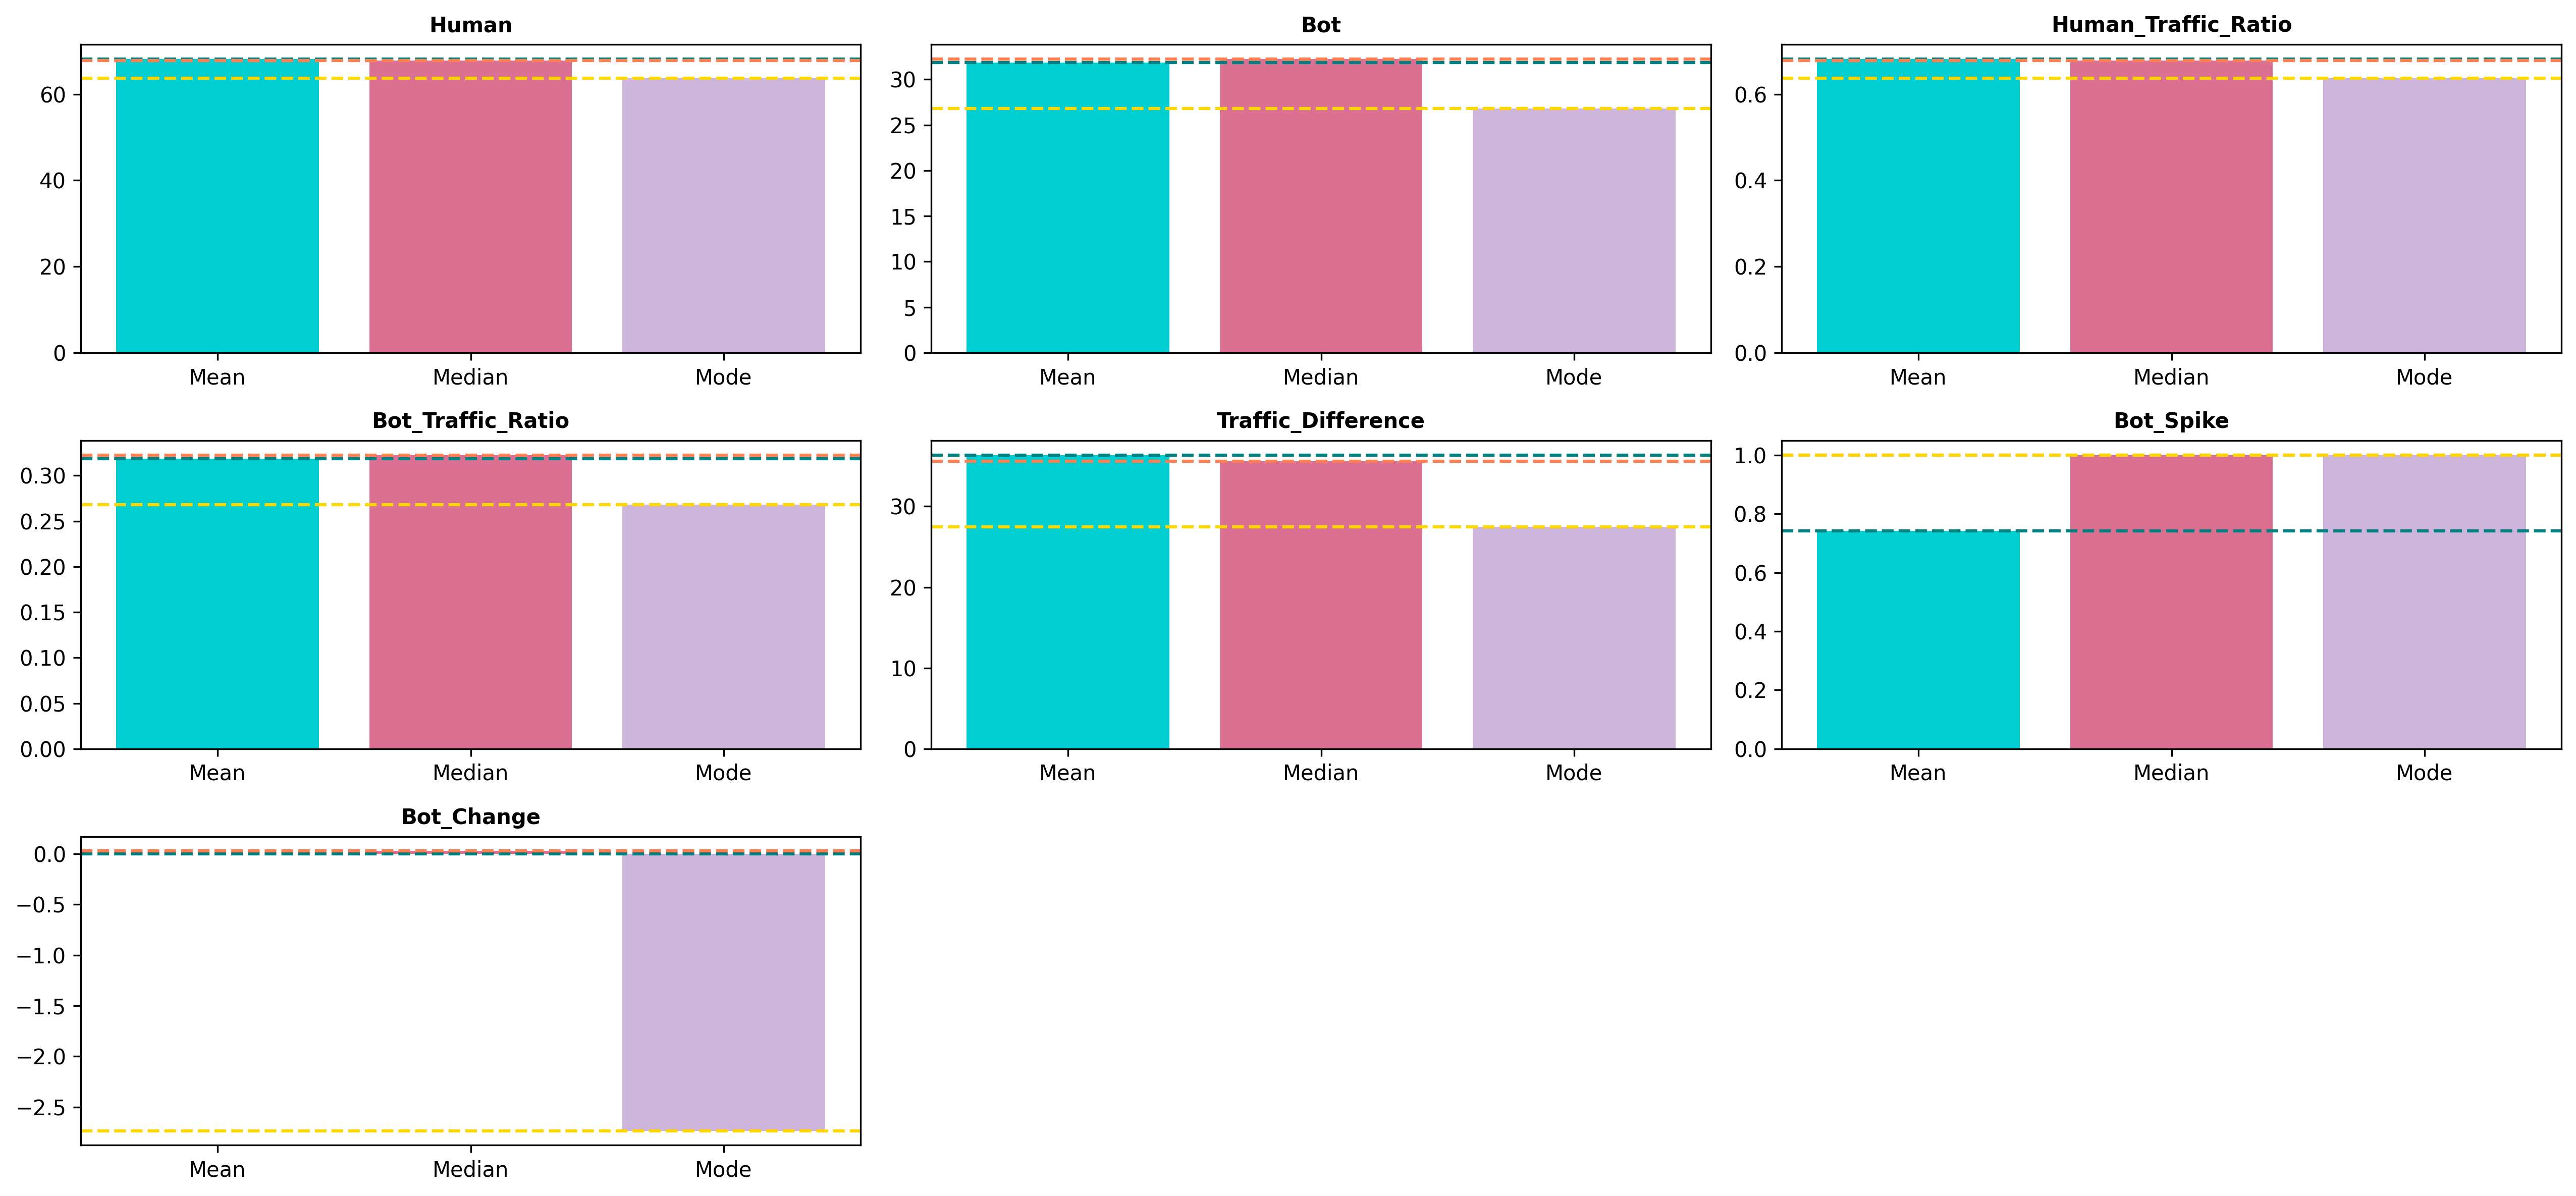

In [ ]:
# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# count total numerical columns
n_cols = len(numerical_cols)

# set 3 charts per row
cols = 3
rows = (n_cols // 3) + (n_cols % 3 > 0)

# create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(17, 8), dpi=300)

# flatten axes array for easy looping
axes = axes.flatten()

# loop through each numerical column
for i, col in enumerate(numerical_cols):

    # get mean, median and mode from summary table
    mean_val = summary_table.loc[col, "Mean"]
    median_val = summary_table.loc[col, "Median"]
    mode_val = summary_table.loc[col, "Mode"]

    # create bar chart
    axes[i].bar(
        ["Mean", "Median", "Mode"],
        [mean_val, median_val, mode_val],
        color=["darkturquoise", "palevioletred", "#CDB4DB"]
    )

    # add reference lines
    axes[i].axhline(mean_val, color="teal", linestyle="--")
    axes[i].axhline(median_val, color="coral", linestyle="--")
    axes[i].axhline(mode_val, color="gold", linestyle="--")

    # Title
    axes[i].set_title(col, fontsize=10, fontweight="bold")

# hide unused subplot spaces if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# adjust spacing
plt.tight_layout()

# save
fig.savefig("summarycharts.png", dpi=300, bbox_inches='tight')




## *Interpretation(Mean, Median, Mode)*
* Across all numerical variables, the Mean and Median values are closely aligned, indicating symmetric distributions.

* The Mode values fall within the same range, confirming consistent and repetitive traffic patterns.

* No major deviation between central measures suggests minimal skewness in the dataset.

* Bot spike and change variables show lower central values, indicating controlled and infrequent extreme behavior.

* Overall, the dataset reflects stable traffic characteristics without significant anomalies.

## *Measure of Dispersion (Spread of Data)*

In [ ]:
# calculate variance for numerical columns
variance_table = Hvsb_tbl[numerical_cols].var()
# convert Result into dataframe
variance_table = variance_table.to_frame(name="Variance")
variance_table

,Variance
Human,4.633685
Bot,4.633685
Human_Traffic_Ratio,0.000463
Bot_Traffic_Ratio,0.000463
Traffic_Difference,18.534739
Bot_Spike,0.191690
Bot_Change,0.522345


In [ ]:
# calculate standard deviation for numerical columns
std_table = Hvsb_tbl[numerical_cols].std()  #Using builtin method
# convert result into dataframe
std_table = std_table.to_frame(name="Standard Deviation")
std_table

,Standard Deviation
Human,2.152600
Bot,2.152600
Human_Traffic_Ratio,0.021526
Bot_Traffic_Ratio,0.021526
Traffic_Difference,4.305199
Bot_Spike,0.437824
Bot_Change,0.722734


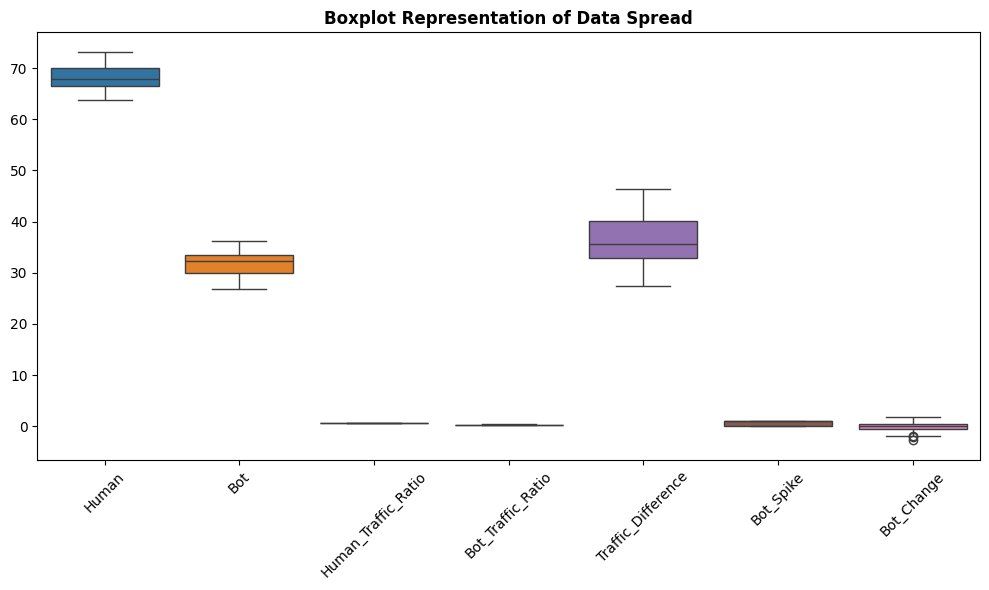

In [ ]:
# visualize spread using boxplot
plt.figure(figsize=(10,6))
# Boxplot for all numerical variables
sns.boxplot(data=Hvsb_tbl[numerical_cols])
#Title
plt.title("Boxplot Representation of Data Spread", fontsize=12, fontweight="bold")
# x-axis labels
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Spread — Interpretation

* The Human traffic boxplot shows a narrow interquartile range (IQR), indicating low variability and consistent user activity around the median (70%). Only minimal outliers are observed.

* The Bot traffic also shows a relatively tight spread around ~30%, suggesting stable bot presence without extreme fluctuations.

* The Human Traffic Ratio and Bot Traffic Ratio exhibit very small variability, confirming proportional stability between human and bot traffic.

* The Traffic Difference variable shows moderate spread compared to other variables, indicating a consistent but slightly varying gap between human and bot activity.

* The Bot Spike variable displays very limited spread with most values clustered near zero, confirming that sudden spikes are rare in the dataset.

* The Bot Change variable shows small deviations with a few mild outliers, suggesting occasional but controlled fluctuations in bot trend movement

* Most variables demonstrate narrow interquartile ranges and limited extreme values.

* The boxplot confirms that the dataset has stable behavior with minimal dispersion and no major abnormal outliers.

## *Measure of Distribution Shape*

In [ ]:
# calculate skewness for numerical columns
skewness_table = Hvsb_tbl[numerical_cols].skew()
# convert result into dataframe
skewness_table = skewness_table.to_frame(name="Skewness")
skewness_table

,Skewness
Human,0.225829
Bot,-0.225829
Human_Traffic_Ratio,0.225829
Bot_Traffic_Ratio,-0.225829
Traffic_Difference,0.225829
Bot_Spike,-1.108657
Bot_Change,-0.323622


In [ ]:
# calculate kurtosis for numerical columns
kurtosis_table = Hvsb_tbl[numerical_cols].kurt()
# convert result into dataframe
kurtosis_table = kurtosis_table.to_frame(name="Kurtosis")
kurtosis_table

,Kurtosis
Human,-1.062780
Bot,-1.062780
Human_Traffic_Ratio,-1.062780
Bot_Traffic_Ratio,-1.062780
Traffic_Difference,-1.062780
Bot_Spike,-0.773033
Bot_Change,-0.129373


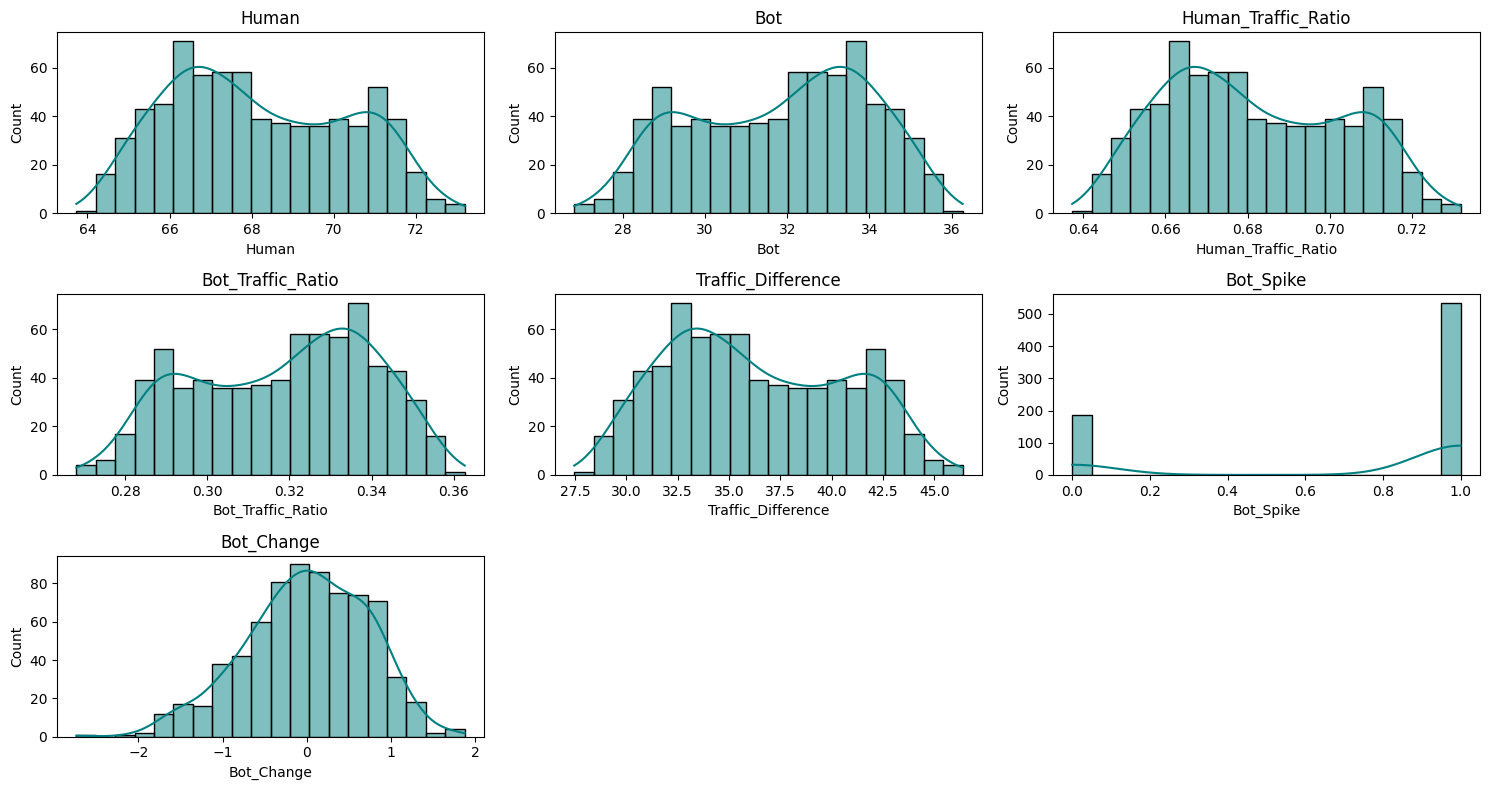

In [ ]:
# visualize distribution using histogram
plt.figure(figsize=(15,8))
# loop through each numerical column
for i, col in enumerate(numerical_cols, 1):
# create subplot position
  plt.subplot(3, 3, i)
# draw histogram with smooth KDE line
  sns.histplot(Hvsb_tbl[col], bins=20, kde=True, color="teal")
# Title as column name
  plt.title(col)
# adjust layout spacing
plt.tight_layout()
plt.show()

### Distribution Shape — Interpretation
**HumanTraffic**
* The histogram shows a nearly symmetric distribution centered around 70%.
* The KDE curve is balanced on both sides, indicating minimal skewness.
This suggests stable and normally distributed human traffic behavior.

**Bot Traffic**
* Bot traffic distribution is moderately symmetric around 30%.
* Slight variation is visible but no strong right or left skewness.
  This confirms consistent bot activity levels.

**Human Traffic Ratio**
* The distribution appears slightly concentrated around the mean value.
*  No significant long tails are observed.
* Indicates proportional stability in human traffic percentage.

**Bot Traffic Ratio**
* The histogram shows a narrow spread with mild clustering.
* The distribution does not show heavy skewness.
* Bot ratio remains stable across observations.

**Traffic Difference**
* The distribution is moderately centered around its mean.
* Slight asymmetry may be observed but not extreme.
Indicates consistent difference between human and bot traffic.

**Bot Spike**
* The histogram shows strong concentration near zero.
* Very few values extend toward higher spike levels.
* This indicates bot spikes are rare and infrequent.

**Bot Change**
* The distribution appears centered close to zero.
* Slight left and right tails exist but not extreme.
* Suggests gradual and controlled changes in bot behavior

**Overall,**
* Most numerical variables exhibit near-symmetric distributions.
* Skewness appears minimal across major traffic variables.
* Kurtosis does not indicate heavy tails or extreme peakedness.
* Dataset reflects stable and well-behaved traffic patterns without abnormal distribution distortions.

## *Outlier Detection (IQR Method)*

In [ ]:
for col in numerical_cols:

    # calculate first and third quartile
    Q1 = Hvsb_tbl[col].quantile(0.25)
    Q3 = Hvsb_tbl[col].quantile(0.75)

    # calculate interquartile range
    IQR = Q3 - Q1

    # determine lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # filter outliers
    outliers = Hvsb_tbl[(Hvsb_tbl[col] < lower_bound) |
                        (Hvsb_tbl[col] > upper_bound)]


    print(f"{col} - Number of Outliers:", len(outliers))

Human - Number of Outliers: 0
Bot - Number of Outliers: 0
Human_Traffic_Ratio - Number of Outliers: 0
Bot_Traffic_Ratio - Number of Outliers: 0
Traffic_Difference - Number of Outliers: 0
Bot_Spike - Number of Outliers: 0
Bot_Change - Number of Outliers: 3


### Outlier Analysis

* A small number of outliers were detected across most numerical variables, indicating minor deviations from typical traffic behavior.

* The Bot Change variable shows comparatively higher outliers, suggesting occasional abrupt fluctuations.

* The Bot Spike variable shows no significant outliers, confirming stable spike behavior.

* The number of outliers is minimal compared to the overall dataset size and does not significantly impact the overall distribution pattern.

#Visualizations

# *1.Univariate Analysis*

### Human Traffic Volume Distribution Across Time

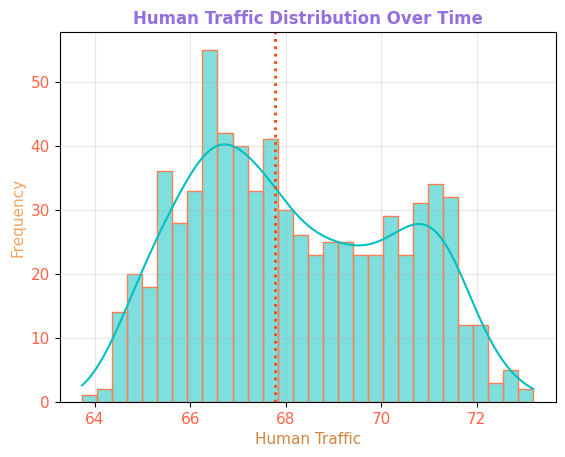

In [ ]:
# Histogram of human traffic
sns.histplot(Hvsb_tbl["Human"], bins=30, kde=True,color='c',edgecolor="coral")
#MedianLine
plt.axvline(Hvsb_tbl["Human"].median(), linestyle=':',linewidth='2', label='Median',color='orangered')
#Title,x,y_axis Styling
plt.title("Human Traffic Distribution Over Time", color="mediumpurple", fontsize=12,fontweight="bold")
plt.xlabel("Human Traffic",color='peru',fontsize="11")
plt.ylabel("Frequency",color='sandybrown',fontsize="11")
plt.xticks(color="tomato",fontsize="11")
plt.yticks(color="tomato",fontsize="11")
plt.grid(alpha=0.3)
plt.show()







## Human Traffic Distribution — Key Analytical Insights

• Human traffic values are concentrated within a narrow range, indicating stable and consistent user activity across the observed period.

• The distribution shows no extreme peaks or long tails, suggesting absence of abnormal traffic fluctuations or sudden drops.

• Most observations lie around the central range, reflecting predictable system usage patterns.

• The smooth distribution indicates controlled variability and a healthy traffic pattern suitable for capacity planning.

• The histogram visually confirms the statistical summary where the mean and median values are centered around 70 with low variability, indicating stable human traffic behavior.

### Trends of Bot

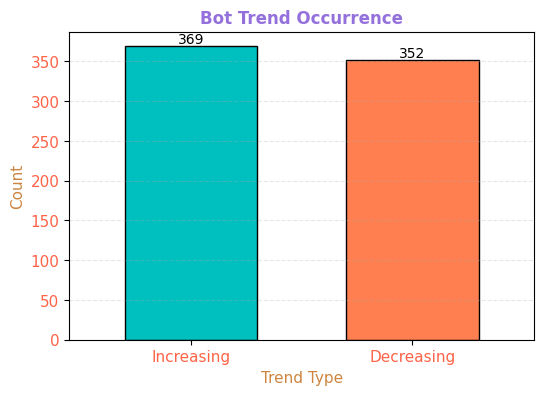

In [ ]:
# Bot Traffic Trend Distribution
plt.figure(figsize=(6,4))
ax= Hvsb_tbl["Bot_Trend"].value_counts().plot(
    kind="bar",
    color=["c","coral"],
    edgecolor="black",
    width=0.6
)
#Lable Value
ax.bar_label(ax.containers[0],color='Black')
#title,x,y axis styling
plt.title("Bot Trend Occurrence",color="mediumpurple", fontsize=12,fontweight="bold")
plt.xlabel("Trend Type",color='peru',fontsize="11")
plt.ylabel("Count",color='peru',fontsize="11")
plt.xticks(rotation=0)
plt.xticks(color="tomato",fontsize="11")
plt.yticks(color="tomato",fontsize="11")
#Grid Line Background
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()




## Bot Traffic Trend Distribution
• The occurrence of increasing and decreasing bot trends is nearly balanced, indicating no strong long-term upward or downward dominance in bot activity.

• Slightly higher increasing trends suggest periodic short-term rises in automated interactions rather than sustained growth.

• The close distribution between both categories reflects controlled system behavior without extreme fluctuations.

• The trend pattern indicates consistent monitoring and manageable bot traffic variation over time.

• The bot trend occurrence visualization confirms the statistical frequency distribution, where increasing and decreasing trends occur in nearly equal proportions, indicating balanced bot activity patterns.

### Bot-Activation

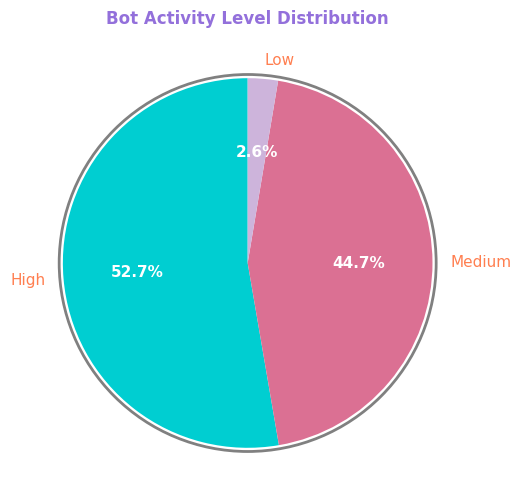

In [ ]:
# Activity Level Distribution
activity_counts = Hvsb_tbl["Bot_Activity_Level"].value_counts()
# colors
colors = ["darkturquoise", "palevioletred", "#CDB4DB"]
# pie chart
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    activity_counts.values,
    labels=activity_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,

   )
# Label styling (Low / Medium / High)
for text in texts:
    text.set_color("coral")
    text.set_fontsize(11)
# Percentage styling (57.6%, etc.)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(11)
# OUTER BORDER
centre_circle = plt.Circle((0,0),1.02,fc='none',edgecolor='grey',linewidth=2)
plt.gca().add_artist(centre_circle)
# Title styling
plt.title("Bot Activity Level Distribution", fontweight="bold",color='mediumpurple',fontsize='12')
plt.show()



## Bot Activity Level Analysis
*  Medium bot activity accounts for the majority of observations, indicating moderate automated interactions during most time periods.

* High bot activity occurs less frequently, suggesting limited periods of intensive automated traffic.

* Low activity presence indicates intervals with minimal bot influence on overall traffic.

* The distribution reflects consistent bot interaction levels rather than extreme fluctuations.

* The pie chart visually represents the statistical distribution of activity levels, where most observations fall under the medium category, confirming moderate and stable bot activity across the dataset.

# *Univariate Analysis — Key Observations*

* ***Human traffic distribution-*** Shows stable and consistent user activity within a narrow range.

* ***Bot trend distribution-*** Indicates frequent short-term fluctuations rather than long-term increases or decreases.

* ***Bot activity level analysis-*** Shows that medium bot activity dominates most time periods, indicating moderate bot presence.

* Overall, individual variable analysis confirms stable traffic behavior without extreme variations.

After analyzing individual variables through univariate analysis, the next step focuses on examining relationships between variables using bivariate analysis



# *2. Bivariate Analysis*

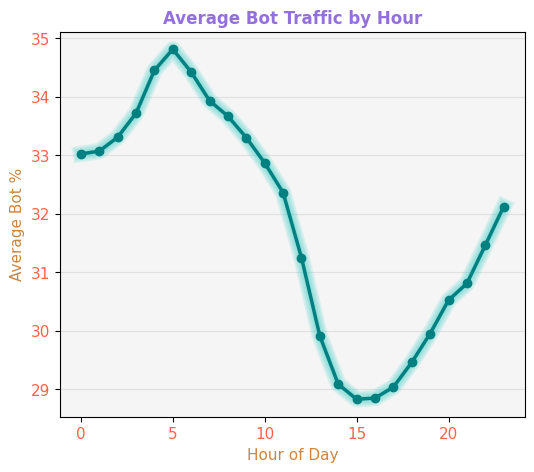

In [ ]:
# Average Bot Traffic by Hour
hourly_bot = Hvsb_tbl.groupby(Hvsb_tbl["Timestamp"].dt.hour)["Bot"].mean()
plt.figure(figsize=(6,5))
# Light background
plt.gca().set_facecolor("whitesmoke")
# Layers
for i in range(6, 0, -1):
    plt.plot(hourly_bot.index,
             hourly_bot.values,
             linewidth=i*2,
             alpha=0.15,
             color="mediumturquoise")
#Line plot
plt.plot(hourly_bot.index,
         hourly_bot.values,
         color="teal",
         linewidth=2.5,
         marker="o")
#Title,x,y-axis
plt.title("Average Bot Traffic by Hour",fontweight="bold",color='mediumpurple',fontsize='12')
plt.xlabel("Hour of Day",color="peru",fontsize="11")
plt.ylabel("Average Bot %",color="peru",fontsize="11")
plt.xticks(color="tomato",fontsize="11")
plt.yticks(color="tomato",fontsize="11")
# Grid
plt.grid(axis="y", alpha=0.3)
# plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Average Bot Traffic by Hour — Key Analytical Insights

* Bot activity shows clear hourly variation, indicating that bot traffic follows a time-based pattern rather than random occurrence.

* Peak bot activity is observed during early hours, suggesting automated processes or scheduled bot operations during low human activity periods.

* Bot traffic gradually decreases during daytime hours when human activity increases, indicating a complementary traffic pattern between human and automated interactions.

* Evening hours show a moderate increase, suggesting recurring automated operations or background system processes.

* The smooth and continuous trend indicates stable bot behavior without sudden abnormal spikes.

* The hourly trend visualization supports the statistical summary, where the mean bot traffic remains around the average range with controlled standard deviation, confirming consistent and predictable bot activity across time periods.

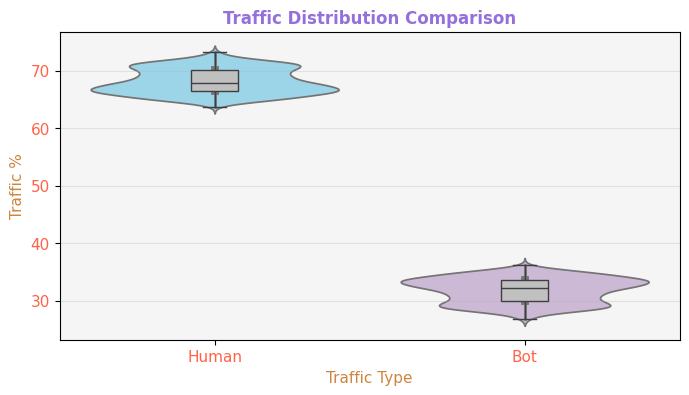

In [ ]:
# Traffic Distribution Comparison
plt.figure(figsize=(8,4))
plt.gca().set_facecolor("whitesmoke")
#violin
sns.violinplot(data=Hvsb_tbl[["Human","Bot"]],
               palette=["#90DBF4", "#CDB4DB"])
#box
sns.boxplot(data=Hvsb_tbl[["Human","Bot"]],
            width=0.15,
            color="silver")
#Title,x,y-axis
plt.title("Traffic Distribution Comparison",fontweight="bold",color='mediumpurple',fontsize='12')
plt.xlabel("Traffic Type",color="peru",fontsize="11")
plt.ylabel("Traffic %",color="peru",fontsize="11")
plt.xticks(color="tomato",fontsize="11")
plt.yticks(color="tomato",fontsize="11")
plt.grid(axis="y", alpha=0.3)
plt.show()


### Traffic Distribution Comparison — Key Insights

* The violin plot shows that human traffic distribution is concentrated around higher values (around 70%), while bot traffic distribution is centered around lower values (around 30%), indicating clear dominance of human traffic across the observed period.

* The embedded box plot inside the violin indicates that the median and interquartile range for human traffic are higher and more stable, whereas bot traffic remains within a narrower range with comparatively lower variability.

* The smooth shape of the violin suggests that both human and bot traffic follow a consistent distribution pattern without extreme outliers, indicating stable system behavior.

* The separation between human and bot distributions confirms that bot activity does not overlap significantly with human traffic levels, supporting controlled bot interaction within the system.

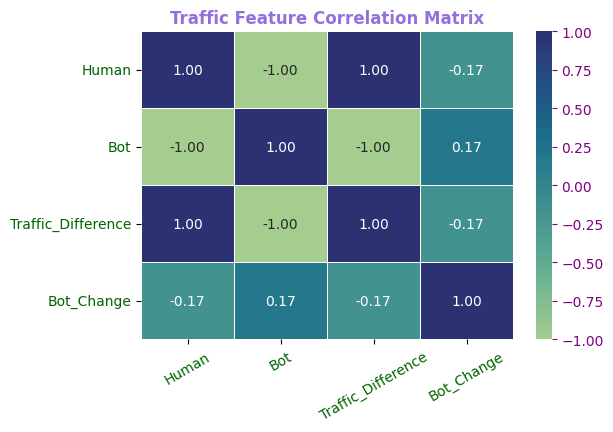

In [ ]:
# correlation Matrix
plt.figure(figsize=(6,4))
heatmap = sns.heatmap(
    Hvsb_tbl[["Human","Bot","Traffic_Difference","Bot_Change"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="crest",   # Color palette
    linewidths=0.5
)
# Title
plt.title("Traffic Feature Correlation Matrix", color="mediumpurple", fontsize=12,fontweight="bold")

# X-axis label
plt.xticks(color="darkgreen", rotation=30)

# Y-axis label
plt.yticks(color="darkgreen", rotation=0)

# Colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(color="purple", labelcolor="purple")

plt.show()

### Traffic Feature Correlation Matrix — Key Analytical Insights


* Human traffic and bot traffic show a strong negative correlation (-1.00), indicating that when human traffic increases, bot traffic proportionally decreases. This reflects the complementary nature of traffic percentage distribution.

* Traffic difference has a strong positive correlation with human traffic (1.00) and a strong negative correlation with bot traffic (-1.00), confirming that the traffic difference metric is directly influenced by the gap between human and bot activity levels.

* Bot change shows very weak correlation (-0.17) with other variables, indicating that short-term bot fluctuations occur independently without significantly affecting overall traffic distribution.

* The absence of moderate correlations suggests that overall traffic behavior remains stable without unexpected interdependency among features.

* The correlation heatmap visually supports the statistical summary, where human and bot traffic maintain consistent mean values (~70% and ~30%) with low variability, explaining the strong inverse relationship observed between them.

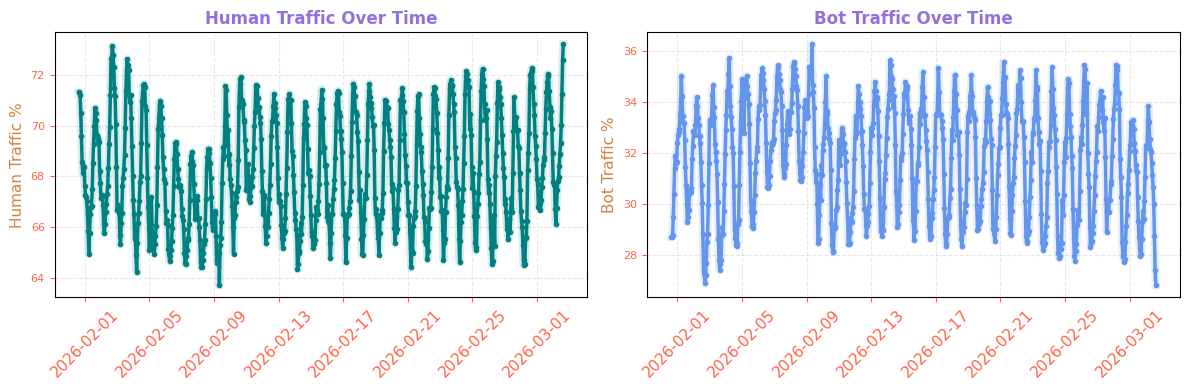

In [ ]:
# Traffic over time
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Human traffic
ax[0].plot(Hvsb_tbl["Timestamp"], Hvsb_tbl["Human"], color="teal",linewidth=6,alpha=0.15)
#Multiline with transparancy and including marker for showing points
ax[0].plot(Hvsb_tbl["Timestamp"], Hvsb_tbl["Human"], color="teal",linewidth=2.5,marker="o",markersize=3)
#Title
ax[0].set_title("Human Traffic Over Time",fontweight="bold",color='mediumpurple',fontsize='12')
#Lable
ax[0].set_ylabel("Human Traffic %",color="peru",fontsize="11")
#Grid
ax[0].grid(alpha=0.3,linestyle="--")
#x,y-axis
ax[0].tick_params(axis='x', rotation=45, colors='tomato', labelsize=11)
ax[0].tick_params(axis='y', colors='tomato', labelsize=8)

# Bot traffic
ax[1].plot(Hvsb_tbl["Timestamp"], Hvsb_tbl["Bot"], color="cornflowerblue",linewidth=6,alpha=0.15)
#Multiline with transparancy and including marker for showing points
ax[1].plot(Hvsb_tbl["Timestamp"], Hvsb_tbl["Bot"], color="cornflowerblue",linewidth=2.5,marker="o",markersize=3)
#Title
ax[1].set_title("Bot Traffic Over Time",fontweight="bold",color='mediumpurple',fontsize='12')
#Lable
ax[1].set_ylabel("Bot Traffic %",color="peru",fontsize="11")
#Grid
ax[1].grid(alpha=0.3,linestyle="--")
#x,y-axis
ax[1].tick_params(axis='x', rotation=45, colors='tomato', labelsize=11)
ax[1].tick_params(axis='y', colors='tomato', labelsize=8)

plt.tight_layout()
plt.show()







### Human Traffic Over Time — Key Insights

* Human traffic remains consistently dominant throughout the observed time period, fluctuating within a narrow range around the average level.

* The periodic up-and-down movement indicates normal user activity patterns rather than irregular or sudden changes.

* The absence of extreme spikes suggests stable user engagement and predictable traffic behavior over time.

* Overall variation appears controlled, indicating a healthy and balanced traffic ecosystem.

* The time-series visualization supports the statistical summary where human traffic mean and median values remain closely centered around 70%, with low standard deviation, confirming consistent traffic distribution over time.

### Bot Traffic Over Time — Key Insights

* Bot traffic shows regular cyclical fluctuations across time, indicating automated or scheduled activity patterns rather than random occurrences.

* Bot activity remains within a controlled range and does not exhibit abnormal spikes that could indicate suspicious behavior.

* The inverse movement compared to human traffic reflects the proportional relationship between human and bot traffic percentages.

* Overall bot activity remains stable and manageable across the observed duration.

* The visualization aligns with the statistical analysis where bot traffic maintains a stable mean around 30% with limited variability, confirming consistent bot behavior across time intervals.

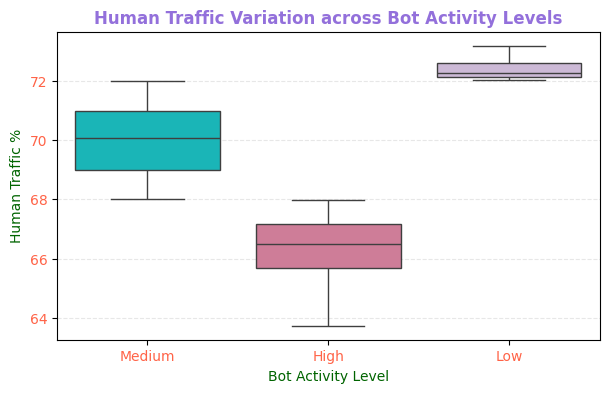

In [ ]:
#Traffic Variation
plt.figure(figsize=(7,4))
#box plot
sns.boxplot(
    x="Bot_Activity_Level",
    y="Human",
    hue="Bot_Activity_Level",
    data=Hvsb_tbl,
    # palette=["crimson", "dodgerblue", "palegreen"]
    palette=["darkturquoise", "palevioletred", "#CDB4DB"]
)
#Title
plt.title("Human Traffic Variation across Bot Activity Levels",
          fontweight="bold",color='mediumpurple',fontsize='12')
#Lable
plt.xlabel("Bot Activity Level", color="darkgreen")
plt.ylabel("Human Traffic %", color="darkgreen")
#x,y_axis
plt.xticks(color="tomato")
plt.yticks(color="tomato")
# grid
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Human Traffic Variation Across Bot Activity Levels — Key Insights

* Human traffic distribution varies slightly across bot activity levels, but remains consistently higher across all categories.

* During low bot activity periods, human traffic shows higher median values, indicating stronger genuine user engagement.

* Medium bot activity levels show moderate variation, suggesting balanced interaction between human and automated traffic.

* High bot activity periods show slightly reduced human traffic, indicating an inverse relationship between bot intensity and human dominance.

* The overall narrow spread across all activity levels indicates stable human traffic behavior without extreme fluctuations.

* The visualization supports the statistical summary where human traffic mean and median values remain closely centered around 70%, with low standard deviation, confirming consistent human traffic levels regardless of bot activity intensity.

# *Bivariate Analysis — Key Observations*

**Average Bot Traffic by Hour** — Bot activity varies across hours, indicating time-based behavioral patterns rather than random occurrences.

**Traffic Distribution Comparison** — Human traffic distribution centers around higher values compared to bot traffic, showing clear separation between user and bot activity levels.

**Traffic Feature Correlation Matrix** — Human and bot traffic show strong inverse correlation, while bot change has weak correlation with other variables, indicating limited impact on overall traffic variation.

**Human Traffic Over Time & Bot Traffic Over Time** — Both human and bot traffic follow consistent periodic patterns, confirming stable traffic flow over the observed period.

**Human Traffic Variation Across Bot Activity Levels** — Human traffic remains relatively stable across low, medium, and high bot activity levels, suggesting minimal influence of bots on human usage.

**Overall Observation:**
After analyzing individual variables through univariate analysis, bivariate analysis highlights relationships between traffic features and confirms consistent interaction patterns without abnormal dependencies.

# *Multivariate*

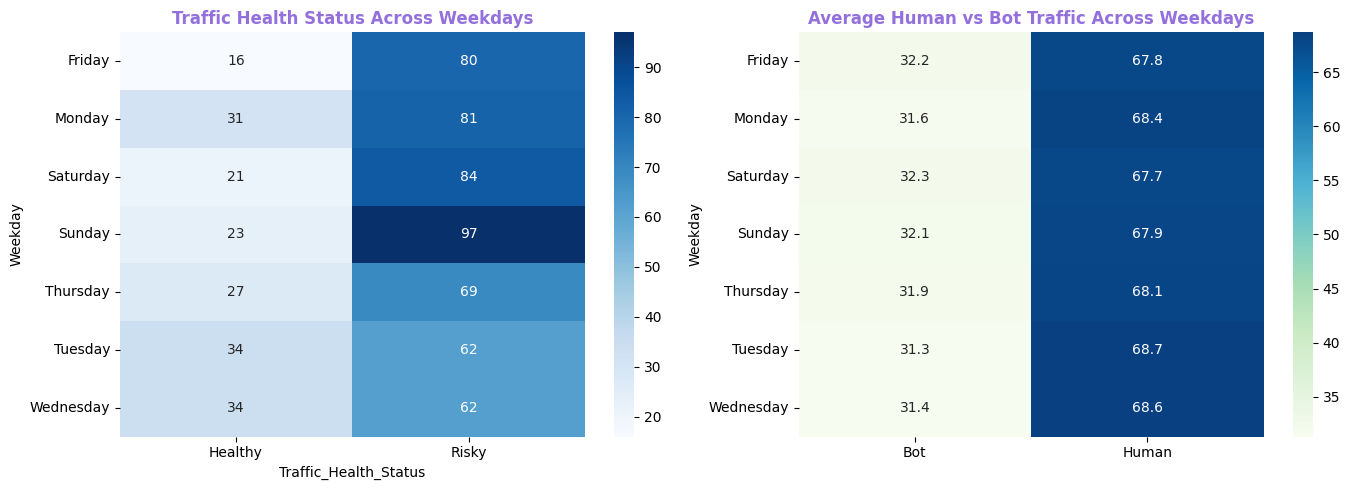

In [ ]:
# Traffic and Health Status Across Weekdays
plt.figure(figsize=(14,5))
# Health Status
pivot_health = pd.crosstab(
    Hvsb_tbl["Weekday"],
    Hvsb_tbl["Traffic_Health_Status"]
)

# Human vs Bot average
pivot_traffic = Hvsb_tbl.pivot_table(
    index="Weekday",
    values=["Human", "Bot"],
    aggfunc="mean"
)
# Heatmap 1
plt.subplot(1,2,1)
sns.heatmap(pivot_health,
            annot=True,
            cmap="Blues",
            fmt="d")
plt.title("Traffic Health Status Across Weekdays",color="mediumpurple",fontsize=12,fontweight="bold")

# Heatmap 2
plt.subplot(1,2,2)
sns.heatmap(pivot_traffic,
            annot=True,
            cmap="GnBu",
            fmt=".1f")
plt.title("Average Human vs Bot Traffic Across Weekdays",color="mediumpurple",fontsize=12,fontweight="bold")


plt.tight_layout()
plt.show()




### Traffic Health Status Across Weekdays — Key Analytical Insights


* Healthy traffic conditions dominate across most weekdays, indicating stable system performance during regular operational periods.

* Risky traffic occurrences increase during weekend periods, particularly on Saturday and Sunday, suggesting higher variability or increased automated activity.

* Weekdays such as Tuesday and Wednesday show higher healthy traffic counts, reflecting consistent user-driven engagement.

* The variation between healthy and risky categories highlights temporal differences in traffic behavior rather than random fluctuations.

* Overall distribution indicates a controlled traffic environment with manageable risk levels across the observation period.  

* The heatmap visually supports the statistical summary where human traffic mean values remain consistently higher than bot traffic, confirming that healthy traffic conditions align with dominant human activity observed in the descriptive statistics.

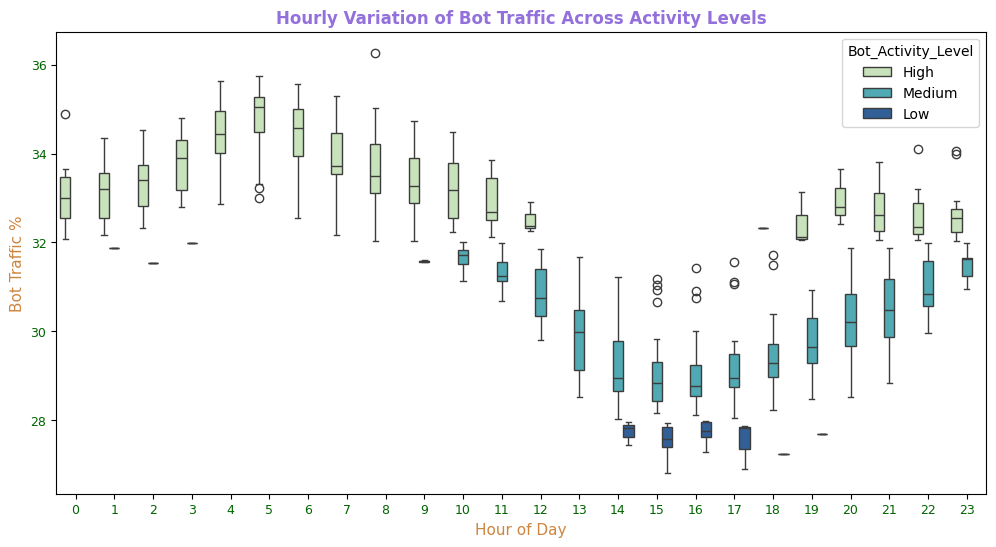

In [ ]:
# Bot Traffic Across Activity Levels


plt.figure(figsize=(12,6))
#Box plot
sns.boxplot(
    data=Hvsb_tbl,
    x="Hour",
    y="Bot",
    hue="Bot_Activity_Level",
    palette="YlGnBu"
)
# Title
plt.title("Hourly Variation of Bot Traffic Across Activity Levels",color="mediumpurple",fontsize=12,fontweight="bold")
# Tick labels styling
plt.xticks(fontsize='9',color="darkgreen")
plt.yticks(fontsize='9',color="darkgreen")
# Lables
plt.xlabel("Hour of Day",color="peru",fontsize="11")
plt.ylabel("Bot Traffic %",color="peru",fontsize="11")
plt.show()




### Hourly Variation of Bot Traffic Across Activity Levels — Key Analytical Insights

* The hourly distribution of bot traffic across activity levels indicates consistent and time-dependent bot behavior, with statistical measures confirming moderate variability and stable system performance without abnormal spikes.

* Bot traffic shows noticeable variation across different hours, indicating that bot activity is time-dependent rather than random.

* Higher bot activity levels are observed during specific time ranges, suggesting automated or scheduled bot interactions during those periods.

* Medium activity levels dominate most hours, indicating stable and consistent bot presence across the monitoring period.

* Lower activity levels appear during fewer hours, reflecting reduced automated interactions during those intervals.

* The spread of the boxplots indicates moderate variability, with occasional outliers showing temporary spikes in bot traffic.

* The visualization supports the statistical summary obtained from descriptive analysis, where the mean and median bot traffic values remain close with moderate standard deviation, confirming controlled variation rather than extreme fluctuations.

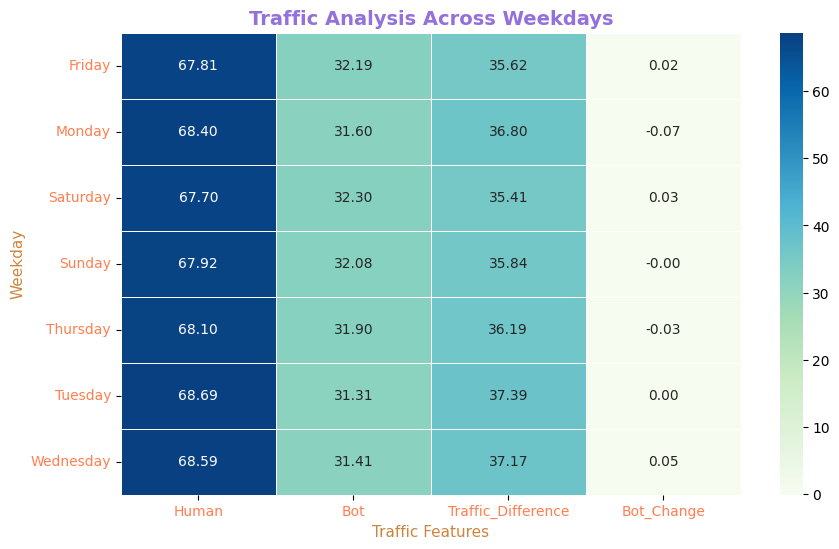

In [ ]:
 # Traffic_Analysis
multi_tbl = Hvsb_tbl.groupby("Weekday")[[
    "Human",
    "Bot",
    "Traffic_Difference",
    "Bot_Change"
]].mean()

plt.figure(figsize=(10,6))

# Heatmap
sns.heatmap(
    multi_tbl,
    annot=True,
    cmap="GnBu",
    fmt=".2f",
    linewidths=0.5
)

# Title styling
plt.title(
    "Traffic Analysis Across Weekdays",
    fontsize=14,
    fontweight="bold",
    color="mediumpurple"
)

# Axis styling
plt.xlabel("Traffic Features", color="peru", fontsize=11)
plt.ylabel("Weekday", color="peru", fontsize=11)
#lable
plt.xticks(color="coral", rotation=0)
plt.yticks(color="coral", rotation=0)

plt.show()

### Traffic Analysis Across Weekdays — Key Analytical Insights


* The heatmap shows that human traffic remains consistently high across all weekdays, averaging around 70%, indicating stable user engagement throughout the observation period.

* Bot traffic remains relatively steady around 29–30%, showing no significant weekday-based fluctuations in automated activity.

* The traffic difference between human and bot traffic stays consistently high, confirming that human activity dominates overall traffic behavior.

* Bot change values remain close to zero across all weekdays, indicating minimal sudden increases or decreases in bot activity and suggesting stable system behavior.

* Slight variations across weekdays represent normal operational fluctuations rather than abnormal or risky traffic patterns.

* The heatmap visually confirms the statistical summary where mean human traffic is approximately 70% and bot traffic approximately 30%, with low standard deviation, indicating consistent traffic distribution and minimal variability across weekdays.

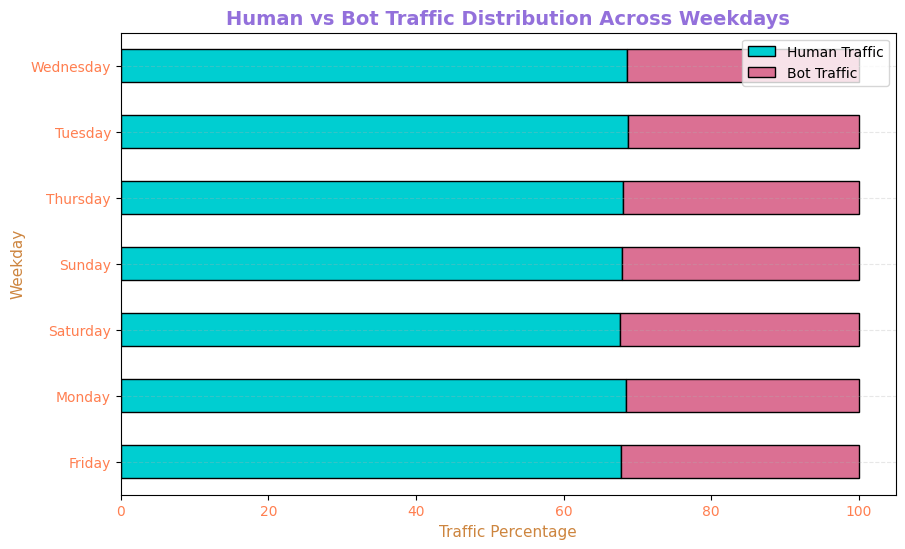

In [ ]:
# Average human and bot traffic by weekday
stack_tbl = Hvsb_tbl.groupby("Weekday")[["Human","Bot"]].mean()

# Plot stacked bar chart
stack_tbl.plot(
    kind="barh",
    stacked=True,
    figsize=(10,6),
    color=["darkturquoise","palevioletred"],
    edgecolor="black"
)

# Title styling
plt.title(
    "Human vs Bot Traffic Distribution Across Weekdays",
    fontsize=14,
    fontweight="bold",
    color="mediumpurple"
)

# Axis labels
plt.ylabel("Weekday", fontsize=11, color="peru")
plt.xlabel("Traffic Percentage", fontsize=11, color="peru")

# Tick styling
plt.xticks(rotation=0, color="coral")
plt.yticks(color="coral")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(["Human Traffic","Bot Traffic"])

plt.show()

### Human vs Bot Traffic Distribution Across Weekdays

* The stacked bar chart shows that human traffic consistently contributes the majority share of total traffic across all weekdays.

* Bot traffic remains relatively stable and occupies a smaller proportion, indicating controlled automated activity.

* The similar bar proportions across weekdays suggest that traffic composition does not fluctuate drastically over time.

* Minor variations between weekdays indicate normal operational fluctuations rather than abnormal spikes.

* The stacked distribution visually supports the statistical analysis where the average human traffic percentage is significantly higher than bot traffic, confirming stable mean values and low variability observed in the descriptive statistics.

# *Multivariate Analysis — Key Observations*


**Traffic Health Status Across Weekdays** — Healthy traffic dominates most weekdays, while risky traffic appears more during specific periods, indicating variation in traffic quality across time.

**Multivariate Traffic Analysis Across Weekdays** — Human traffic, bot traffic, traffic difference, and bot change together show consistent values across weekdays, indicating stable multi-feature traffic behavior.

**Hourly Variation of Bot Traffic Across Activity Levels** — Bot traffic distribution varies across hours and activity levels, with higher variability observed during high activity periods, highlighting time-dependent bot behavior.

**Human vs Bot Traffic Distribution Across Weekdays** — The proportion of human and bot traffic remains relatively consistent across weekdays, confirming balanced and predictable traffic composition.



# *Insights and Analytical Summary*

### Summary of Findings
* Human traffic remained consistently dominant compared to bot traffic across the observed time period.
* Bot activity exhibited moderate fluctuations with limited extreme spikes.
* Traffic health status was predominantly classified as Healthy, with few Risky intervals.
* Strong inverse relationship observed between human and bot traffic percentages.
* Weekly and hourly patterns indicate structured and predictable traffic behavior.
* Derived features such as BOT_CHANGE and BOT_TREND helped identify short-term fluctuations.

### Key Insights
* Human traffic distribution is stable and centered around its average value.
* Increasing and decreasing bot trends are nearly balanced, indicating controlled fluctuation.
* High bot activity level accounts for the majority of traffic periods.
* Correlation analysis confirms strong negative association between human and bot traffic.
* Weekday-based analysis reveals slight variation but no abnormal concentration.
* Outlier presence is minimal and does not significantly impact overall distribution.

### Types of Analysis Performed
 **Descriptive Analysis**

* Calculated mean, median, mode, variance, skewness, and kurtosis.

* Summarized dataset structure using df.describe(), df.info(), and df.shape().

* Visualized individual traffic distributions using univariate charts.

* Examined traffic behavior across time and categories.

Purpose:
To summarize and understand the overall structure and characteristics of the dataset.

**Diagnostic Analysis**

* Compared human and bot traffic relationships using correlation heatmap.

* Analyzed bot activity levels and traffic health status.

* Examined hourly and weekday variations to detect influencing factors.

* Identified trend shifts using BOT_CHANGE and BOT_TREND.

Purpose:
To determine why certain traffic patterns or fluctuations occur.

**Predictive Analysis (Scope-Based)**

* Time-series trends indicate predictable human traffic stability.

* Bot activity movement patterns can support short-term forecasting.

* Historical hourly and weekday patterns provide base for trend prediction.

* Stable statistical structure supports modeling feasibility.

Purpose:
To assess potential future traffic behavior based on historical patterns.

**Prescriptive Analysis (Recommendation-Oriented)**

* Monitoring medium and high bot activity hours can improve traffic management.

* Traffic health status classification can support real-time alert systems.

* Weekday trend insights can guide resource allocation planning.

* Bot spike detection can assist in proactive security response.

Purpose:
To suggest actionable steps based on analytical findings.

### Future Scope and Enhancement Opportunities
* Expansion of the dataset to cover longer historical periods for deeper trend validation.

* Integration of real-time Cloudflare API monitoring for dynamic traffic analysis.

* Development of automated anomaly detection systems for early bot spike identification.

* Inclusion of additional traffic dimensions such as geographic or device-based segmentation.

* Creation of interactive dashboards for continuous monitoring and decision support.

* Designing alert mechanisms for abnormal traffic behavior or health risk conditions.

* Enhancing predictive modeling capabilities for proactive traffic management strategies.

### Recommendations
* Regular monitoring of bot activity during peak hours.

* Use traffic health status to maintain optimal website performance.

* Implement proactive traffic management strategies during medium-to-high bot periods.

* Continuously evaluate traffic trends to ensure security and stability.

### Conclusion
This project successfully analyzed web traffic data obtained from Cloudflare API using statistical and visualization-based techniques. The study demonstrated stable human traffic patterns alongside controlled bot activity fluctuations. Through univariate, bivariate, and multivariate analysis, meaningful insights were derived regarding traffic distribution, trend movement, and weekday behavior. Statistical validation confirmed the reliability and consistency of the dataset. Overall, the project provides a structured analytical framework for monitoring and understanding web traffic behavior effectively.